# Mixed-Field Ising Model (MFIM) evolution using Matrix Product Operator (MPO) and Pauli chain Propagation

I've written some Julia module,
- `matrix_product_operator_functions.jl`, based on the MPO evolution method and the `ITensors.jl` (and `ITensorMPS.jl`) package for managing tensors,
- `pauli_propagation_functions.jl`, based on the paper “*Pauli Propagation: A Computational Framework for Simulating Quantum Systems*” and the associated package `PauliPropagation.jl`,
- `exact_functions.jl`, which simply calculates the “theoretical,” exact results of a propagation,
- `circuit.jl`, which allows you to initialize different types of circuits, including the MFIM, for the different methods we will need in this notebook.

These module allows me to handle propagation of an observable (in the Heisenberg picture) through a quantum circuit.

To test the different methods, we'll first focus on a simple, well-understood system to validate the method and develop our intuition before moving on to more complex circuits in future notebooks.

In [149]:
# using Pkg; Pkg.add("LaTeXStrings"); Pkg.add("PauliPropagation"); Pkg.add("ITensors"); Pkg.add("ITensorMPS")

In [150]:
using LaTeXStrings
using Plots
using LinearAlgebra
import Statistics: mean

# --- Pauli Propagation ---
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

# --- Exact method ---

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# --- other ---
#include("../src/utils.jl")
include("utils.jl")
import .utils as us

#include("../src/circuit.jl")
include("circuit.jl")
import .circuit as ct

# 1. Introduction

We consider a system of $n$ qubits arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates U** applied in a **bricklayer pattern**.

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

We will discretize the time, and a layer is applied every $\tau=0.1$ time step.

In [151]:
τ = 0.1

# Brick layer topology exemple
nqubits = 4
topology = bricklayertopology(nqubits; periodic=false)

3-element Vector{Tuple{Int64, Int64}}:
 (1, 2)
 (3, 4)
 (2, 3)

$j$ and $j+1$ are the topological tuples, so they are the nearest neighbors here.

So each layer consists of **nearest-neighbor gates** of the form:

$$
U_{j, j+1} = e^{-i \theta H_{j,j+1}}
$$

This type of evolution corresponds to a **Trotterized time evolution** under an **MFIM Hamiltonian**, $H$.

$$
H = \sum_j ( X_j X_{j+1} + gX_j + hZ_j ) \quad \text{with} \quad g=1/2, h=1/2
$$

where $X_j$ is the Pauli X operator acting on qubit $j$ (same for $Z_j$), and $\theta$ which is, in our case $\tau$, a fixed parameter (Trotter step).

For the Pauli propagation method, one can simply create a circuit that applies the correct layers :



In [152]:
# Circuit exemple
g, h = 0.5, 0.5
steps = 50

MFIM_circuit_pp = ct.pp_TFIM_circuit(nqubits, steps; topology)
parameters = ones(countparameters(MFIM_circuit_pp)) * τ # all the \theta are τ

println("Gates in the circuit : ", length(parameters))

Gates in the circuit : 150


## 1.1 Trotter decomposition

Whereas, for the method using tensors, we will need to decompose our layers

$$H = \sum_j h_{j,j+1} \quad \text{where} \quad h_{j,j+1} = X_jX_{j+1} +\frac{g}{2}( X_j+X_{j+1})+\frac{h}{2}( Z_j+Z_{j+1})$$

$H$ can be decompose between $j_{odd}$ and $j_{even}$ so $H = H_{odd} + H_{even}$.

We take a small time step $\tau << 1$,
we can use the Baker-Campbell-Hausdorff formula to approximate :

$$U(\tau) = e^{-i \tau H} = e^{-i \tau (H_{odd} + H_{even})} = e^{-i \tau H_o} e^{-i \tau H_e} e^{-i \tau^2 [H_o,H_e]} = e^{-i \tau H_o} e^{-i \tau H_e} + O(\tau^2)$$
because of
$$e^{-i \tau^2 [H_o,H_e]} = \mathbb{I} - i \tau^2 [H_o, H_e] + O(\tau^4) $$

We have an error per time step $\tau$ of order $\tau^2$.

the $h_{j,j+1}$ for $j$ odd or even commute with each other, so

$$e^{-i \tau H_o} = e^{-i \tau \sum_{j_{odd}}h_{j,j+1}} = \prod_{j_{odd}} e^{-i \tau h_{j,j+1}} $$

same for $H_{even}$.

in conclusion we take

$$U^{TEBD2}(\tau) = e^{-iH\tau} \approx \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2} \prod_{j_{even}}e^{-i\tau h_{j,j+1}} \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2}$$

Wich have an error order of $\tau^3$.

Each term: $e^{-i\tau h_{j,j+1}}$ acts only on 2 spins.
Therefore, it can be represented as a 4-index tensor.
This is called a **TEBD gate**.

In [153]:
# Circuit exemple

MFIM_circuit_mpo, sites = ct.mpo_MFIM_circuit(nqubits, steps; τ, g, h)

println("Gates in the circuit : ", length(MFIM_circuit_mpo)*length(MFIM_circuit_mpo[1]))

Gates in the circuit : 250


---

## 1.1 Heisenberg picture

Instead of evolving a quantum state, we study the evolution of an observable $O$ in the Heisenberg picture:

$$
O(t) = U^\dagger O U
$$

In this notebook, we choose as initial observable a local Pauli operator:

$$
O = Z_i
$$

In [154]:
Z_2_pauliString = PauliString(nqubits, :Z, 2) # IZI...I

PauliString(nqubits: 4, 1.0 * IZII)

Local observable implies max link dim need to be 1.

In [155]:
ops = ["Id" for n in 1:nqubits]
ops[2] = "Z"
Z_2_mpo = MPO(sites, ops)
println("Max link dimension = ", maxlinkdim(Z_2_mpo))

Max link dimension = 1


---

## 1.2 Pauli chain propagation method

The key idea of **Pauli propagation** is to express the observable as a **sum of Pauli strings**:

$$
O = \sum_\alpha c_\alpha P_\alpha
$$

and to propagate each Pauli string through the circuit.

$P_\alpha$ a Pauli string is a tensor product of $\{I, X, Y, Z\}$, the Pauli matrices.

Exemple :
- for 5 qubits, it can be $X\otimes I \otimes Y\otimes I \otimes I$

Under conjugation by quantum gates, Pauli strings transform into linear combinations of other Pauli strings (and we call this type of object : `PauliSum`). This leads to a growth in the number of terms, which is controlled in practice using:

- **truncation of small coefficients** (if $c_\alpha < $ `min_abs_coeff` we truncate him)
- **limitation of the Pauli weight** (if $P_\alpha$ contains more than `max_weight` non identity Pauli matrices, we delete him)

This method is particularly efficient when the operator remains relatively **sparse in the Pauli basis**.

In [156]:
# truncations exemple
max_weight = 3 # the max is nqubits
min_abs_coeff = 1e-4 # the min is 0.

0.0001

So propagating a Pauli string through a circuit transforms it into a Pauli sum.

We can use the `propagate` function from the package directly, but in the rest of this notebook we will use my `propagate_layerbylayer` function, which allows us to **calculate the evolution** of some physical quantity.

In [157]:
# propagation exemple
Z2_t_pauli_sum = propagate(MFIM_circuit_pp, Z_2_pauliString, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 4, 4 Pauli terms:
 -0.91954 * XZXI
 -0.27201 * XYII
 0.080464 * IZII
 -0.27201 * IYXI
)

We need to pay attention to the values of our truncations to avoid diverging from the exact solutions. We can verify whether our method is always implemented correctly by measuring the **norm of the observable**, which should be close to 1.

$$\sum_\alpha |c_\alpha|^2 = 1$$

In [158]:
norm = pp.pauli_norm(Z2_t_pauli_sum)

1.000000000000012

---

## 1.3 MPO and Max bond dimenstion ($\chi$)

With the MPO method, we use a cutoff to reduce computation time.
When the max link dimension reaches $2^N$, the max bond dimension, this means either that our system is far too entangled, or that our cutoff is not large enough.

In [159]:
# Truncations
cutoff = 1e-8 # the min is 0.
maxdim = 500 # the max is 2^nqubits

500

The simpliest MPO possible, are the local operator, we can take identity.

In [160]:
# MPO identity construction
IdMPO = MPO(sites, "Id")

println("Max link dimension = ", maxlinkdim(IdMPO))

Max link dimension = 1


 max link dimension $= 1 \implies \chi = 1$.

Let's test the robustness of our method by verifying a simple result.

If $\hat{O} = \mathbb{I}$ we have :

$$U^\dagger \mathbb{I} U = \mathbb{I} \qquad \forall U \text{ unitary}$$



In [161]:
ψ0_mps = MPS(sites, "0") # |↑↑..↑>
IdMPO_t, result_id = mpo.propagate_layerbylayer(MFIM_circuit_mpo, IdMPO; cutoff, maxdim, ψ0=ψ0_mps)

println("Max bond dimension = ", maxlinkdim(IdMPO_t))
println("\nIdentity distance = ", ITensors.norm(IdMPO_t - IdMPO))

layer : 5 /50 complete
layer : 10 /50 complete
layer : 15 /50 complete
layer : 20 /50 complete
layer : 25 /50 complete
layer : 30 /50 complete
layer : 35 /50 complete
layer : 40 /50 complete
layer : 45 /50 complete
layer : 50 /50 complete
Time taken by mpo_functions.propagate_layerbylayer: 0.3137788772583008 seconds
Max bond dimension = 1

Identity distance = 5.108350436597412e-15


This indeed gives the expected result:
$$U^{\dagger}\mathbb{I}U = \mathbb{I}$$

After applying the evolution, we arrive back at the identity, with a **numerical error** of the order of $10^{-14}$ for $100$ steps.

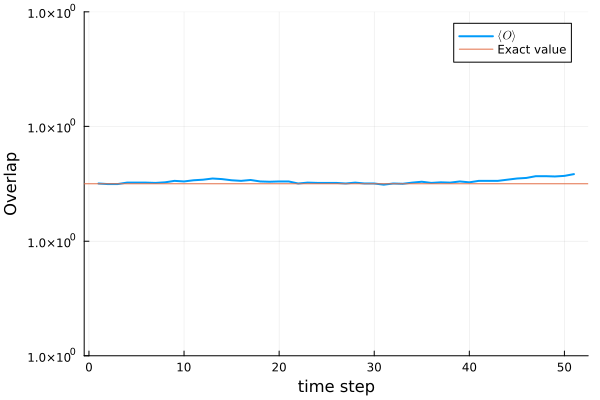

print device already activated
GKS: Possible loss of precision in routine SET_WINDOW


Average Overlap : 1.0000000000000016 ≈ 1


In [162]:
overlap_values = result_id["overlap"]

dy = 1e-13
p = plot(overlap_values,
     xlabel="time step",
     ylabel="Overlap",
     label=L"\langle O \rangle",
     lw=2,
     ylims=(1-dy,1+dy))

hline!(p, [1], label="Exact value")
display(p)

println("Average Overlap : ", mean(overlap_values)," ≈ 1")

And the overlap $\langle \uparrow | \mathbb I | \uparrow \rangle \approx 1 \pm10^{-14}$.

---

# 2. Quantities and measurements

We just talked about overlap, let's define these quantities.

## 2.1 Overlap with the intial state $|0\rangle$

To test the method, we will examine the evolution of a physical quantity called the overlap, which is a trace between the operator and the density operator.

For the method that uses Pauli sums, it is easier to calculate the overlap with the zero state, since:

$$\langle A \rangle_{\psi(t)} = \langle \psi_0 | U^\dagger A U | \psi_0\rangle = \langle \psi_0 | A(t) | \psi_0\rangle = \langle \psi_0 | \sum_k c_k(t) P_k | \psi_0\rangle$$

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle \psi_0 | P_k | \psi_0\rangle$$

We know :
- $\langle 0 | I | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | Z | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | X | 0 \rangle = \langle 0 | 1 \rangle = 0$
- $\langle 0 | Y | 0 \rangle = i \langle 0 | 1 \rangle = 0$

So if the initial state $| \psi_0 \rangle = |00\dots0\rangle$ :

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle 00\dots0 | P_k | 00\dots0\rangle = \sum_{\alpha} c_\alpha(t)$$

where $\forall \alpha$, the pauli string $P_\alpha$ contains **only** the identity $I$ and the operator $Z$.

In [163]:
function compute_overlapwithzero(pauli_sum::PauliSum)
  result = 0.0
  for (pauli_string, coeff) in pauli_sum
      string = pp.decode_pauli(pauli_string, pauli_sum.nqubits) # give the pauli string P_\alpha like "IXIZ"
      if !(contains(string, "X") || contains(string, "Y"))
          result += real(coeff)
      end
  end
  return result
end

compute_overlapwithzero (generic function with 1 method)

But in `PauliPropagation.jl` package we have a function `overlapwithzero()` which does exactly the same thing :

In [164]:
overlap1 = compute_overlapwithzero(Z2_t_pauli_sum)
overlap2 = overlapwithzero(Z2_t_pauli_sum)

println("The two overlap are close : ", (overlap1 ≈ overlap2))

The two overlap are close : true


---

## 2.2 Correlation function

Features to add

---

# 3. Implementation of the method

## 3.1 Initialisation

We will test our methods on the observable $Z_i$ with $i=2$, which will be propagated through a circuit representing the time evolution under a **TFIM** and then an **MFIM Hamiltonian**, over 150 time steps for 4, 5, 6, 7, and 8 qubits.

In [165]:
steps, i = 150, 2

Ns = 4:8

4:8

In [166]:
function initialisation(nqubits::Int64, steps::Int64, g::Float64, h::Float64, τ::Float64, i::Int64=2)
  # exact
  Z_i = ext.get_Zi(nqubits, i)
  circuit_exact = ct.exact_circuit_MFIM(nqubits, τ/2, steps, g, h) # g and h = 0 => TFIM circuit
  ψ0_exact = append!([1.],[0. for _ in 2:(2^nqubits)]) # |0> state

  # Pauli
  ## init circuit
  topology = bricklayertopology(nqubits; periodic=false)
  circuit_pp, parameters = ct.pp_MFIM_circuit(nqubits, steps; g, h, topology)

  ## init observable
  Z_i_pauliString = PauliString(nqubits, :Z, i) # IZI...I

  ## init initial state
  ψ0_pp = ψ0_exact # |0> state
  # MPO
  ## init circuit
  circuit_mpo, sites = ct.mpo_MFIM_circuit(nqubits, steps; τ=τ/2, g, h) # with g, h = 0

  ## init observable
  ops = ["Id" for n in 1:nqubits]
  ops[i] = "Z"
  Z_i_mpo = MPO(sites, ops)

  ## init initial state
  ψ0_mps = MPS(sites, "0") # |↑↑..↑>

  return circuit_exact, Z_i, ψ0_exact, circuit_pp, Z_i_pauliString, parameters, ψ0_pp, circuit_mpo, sites, Z_i_mpo, ψ0_mps
end

initialisation (generic function with 2 methods)

We want to see how the **complexity** and **computation time of propagation increase** for the methods as a function of the size of the spin chain, the number of qubits.

But since the number of qubits varies, we'll need to find the truncation for each system. We cannot do this by hand, but a function of the module, `find_truncations()`, will test several truncations for us, from the coarsest to the most accurate; when, for two consecutive truncation tests, the overlap curve converges to the same result with a possible error of `truncation_tolerance` : $10^{-2}$, we keep this truncation, assuming it is correct.


In [167]:
truncation_tolerance = 1e-2 # for finding the truncations

0.01


After propagating our observable with these found truncations, we will compare our method by comparing the observalble we got, $\hat O(t_{final})$, and the time-dependent overlap of a $\psi_0$ state ($\langle \psi_0 | \hat O(t) | \psi_0\rangle$) with the exact method.

By default, the wave functions in the modules take the state $|\psi_0 \rangle = | 0 \dots 0 \rangle$.

Numerical error for the matrix result is calculate with the mean of the absolute error, `mean(abs.(matrix1 .- matrix2))`,

And for the Overlap we take the maximum of the absolute error at each time `maximum(abs.(overlap1 .- overlap2))`,

We compare this with the error tolerance to see if the method converge to the exact result.

In [168]:
error_tolerance = 1e-1 # for the matrix and overlap comparaison with exact result

0.1

---

## 3.2 TFIM Hamiltonian

$$
H = \sum_j X_j X_{j+1}
$$

--------------- nqubits=4 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.031182050704956055 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=4, Min abs coeff=1e-4)
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.003731966018676758 seconds
--------- MPO method propagation ---------
Optimal truncations find : (Maxdim=5, Cutoff=1e-6)
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complet

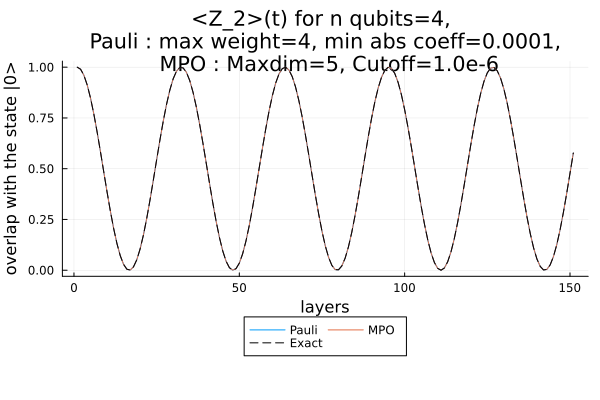

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? false
Mean matrix error (Pauli): 2.435322822262478e-6
Mean matrix error (MPO): 0.12350395301160928

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 1.9586802681094445e-5
Max overlap error (MPO): 8.104628079763643e-15
--------------- nqubits=5 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.005434989929199219 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=4, Min abs coeff=1e-4)
layer : 15/150 complete
layer : 30/150 complete
layer :

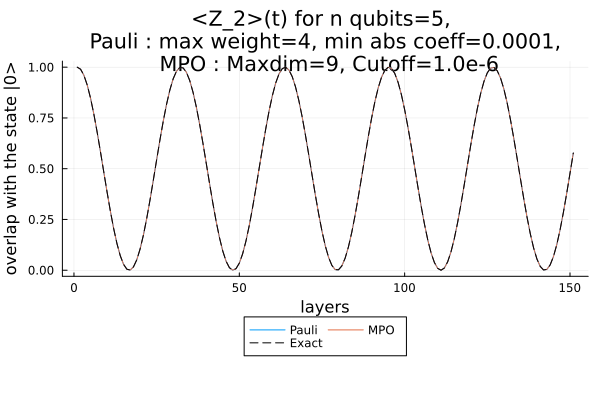

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 1.2176614113593538e-6
Mean matrix error (MPO): 0.06175197650580549

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 1.9586802677571798e-5
Max overlap error (MPO): 1.865174681370263e-14
--------------- nqubits=6 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.11012005805969238 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=4, Min abs coeff=1e-4)
layer : 15/150 complete
layer : 30/150 complete
layer : 

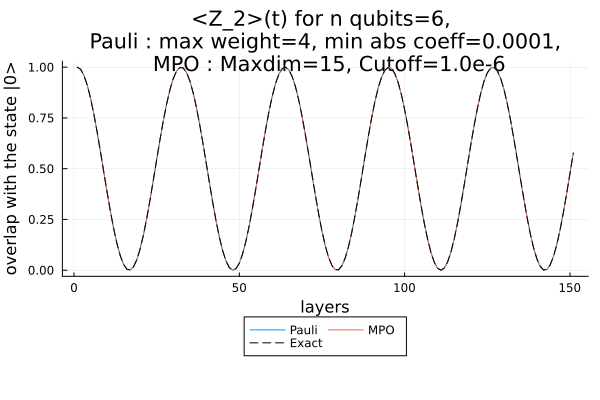

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 6.088307059075071e-7
Mean matrix error (MPO): 0.030875988252902997

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 1.9586802680192887e-5
Max overlap error (MPO): 4.196643033083092e-14
--------------- nqubits=7 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.2759430408477783 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=4, Min abs coeff=1e-4)
layer : 15/150 complete
layer : 30/150 complete
layer : 4

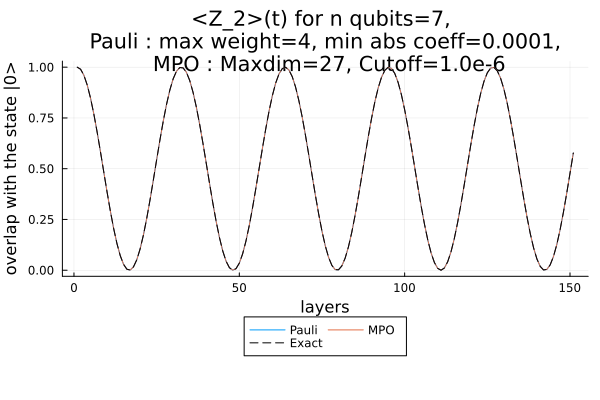

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 3.044153532269182e-7
Mean matrix error (MPO): 0.015437994126451797

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 1.9586802676296058e-5
Max overlap error (MPO): 4.96269692007445e-14
--------------- nqubits=8 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 2.9284701347351074 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=4, Min abs coeff=1e-4)
layer : 15/150 complete
layer : 30/150 complete
layer : 45

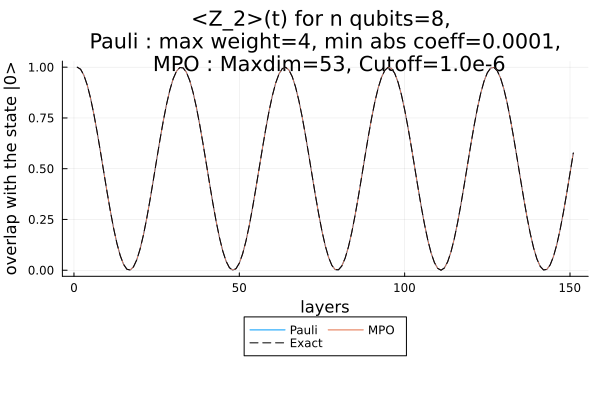

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 1.5220767671059865e-7
Mean matrix error (MPO): 0.00771899706322617

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 1.958680267693589e-5
Max overlap error (MPO): 1.0724754417879012e-13


In [169]:
TFIM_times_exact, TFIM_times_pp, TFIM_times_mpo = Float64[], Float64[], Float64[]
TFIM_truncations_mpo, TFIM_truncations_pp = Tuple{Int64, Float64}[], Tuple{Int64, Float64}[]

for nqubits in Ns
  println("--------------- nqubits=$nqubits ---------------")
  # Init methods
  TFIM_circuit_exact, Z_i, ψ0_exact, TFIM_circuit_pp, Z_i_pauliString, parameters, ψ0_pp, TFIM_circuit_mpo, sites, Z_i_mpo, ψ0_mps = initialisation(nqubits, steps, 0., 0., τ, i)

  # Exact method
  println("--------- Exact method propagation ---------")
  Zi_t_exact, result_exact = ext.propagate_layerbylayer(TFIM_circuit_exact, Z_i; ψ0=ψ0_exact)
  overlap_exact = result_exact["overlap"]

  # Pauli
  println("--------- method Pauli propagation ---------")
  ## test truncation
  (max_weight, min_abs_coeff) = pp.find_truncations(truncation_tolerance, TFIM_circuit_pp, Z_i_pauliString, steps, parameters)

  ## optimal truncation application
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(TFIM_circuit_pp, Z_i_pauliString, steps, parameters; max_weight, min_abs_coeff, ψ0=ψ0_pp)
  overlap_pp = result_pp["overlap"]

  ## pauli sum -> matrix
  Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)

  # MPO
  println("--------- MPO method propagation ---------")
  ## test truncation
  (maxdim, cutoff) = mpo.find_truncations(truncation_tolerance, TFIM_circuit_mpo, Z_i_mpo)

  ## optimal truncation application
  Zi_t_mpo, result_mpo = mpo.propagate_layerbylayer(TFIM_circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0=ψ0_mps)
  overlap_mpo = result_mpo["overlap"]

  ## Itensor -> matrix
  Zi_t_mpo_matrix = mpo.compute_matrix(Zi_t_mpo, sites)

  # plot and print to see if its good
  println("--------- Plot & Result ---------")
  us.overlap_with_Zi_plot(nqubits, overlap_pp, overlap_mpo, overlap_exact, i, max_weight, min_abs_coeff, maxdim, cutoff)
  us.print_methods_error(Zi_t_exact, Zi_t_pauli_propagation_matrix, Zi_t_mpo_matrix, overlap_exact, overlap_pp, overlap_mpo, error_tolerance; operatorName="Z$i")

  # push the time of propagation to see complexity
  push!(TFIM_truncations_pp, (max_weight, min_abs_coeff))
  push!(TFIM_truncations_mpo, (maxdim, cutoff))
  push!(TFIM_times_exact, result_exact["time"])
  push!(TFIM_times_pp, result_pp["time"])
  push!(TFIM_times_mpo, result_mpo["time"])
end

We obtain the same $Z_i(t_{final})$, barring a numerical error of $10^{-14}$ and the same overlap curve along the $150$ evolution steps.

We can see that for this type of circuit, our **result remains very close with weak truncations**, the result is close to the exact with a tolerance of $10^{-14}$.

This close result is because the **Pauli strings and Max link do not become complex in this type of circuit**, so truncation has very little effect, which prevents our results from diverging from the case without truncation.


## 3.3 TFIM result

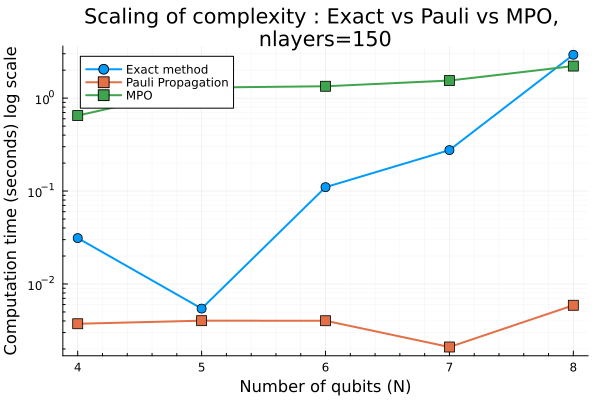

In [170]:
us.complexity_plot(Ns, steps, TFIM_times_exact, TFIM_times_pp, TFIM_times_mpo; logscale=true)

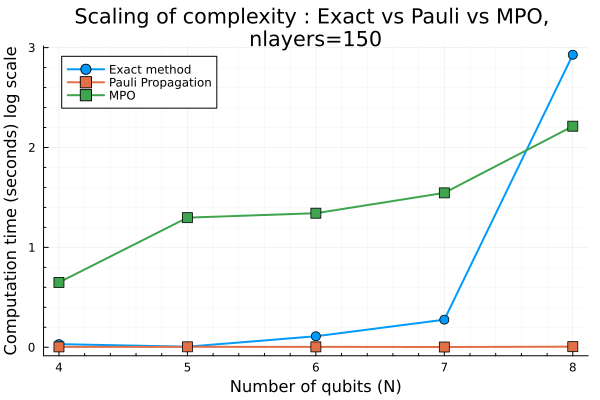

In [171]:
us.complexity_plot(Ns, steps, TFIM_times_exact, TFIM_times_pp, TFIM_times_mpo)

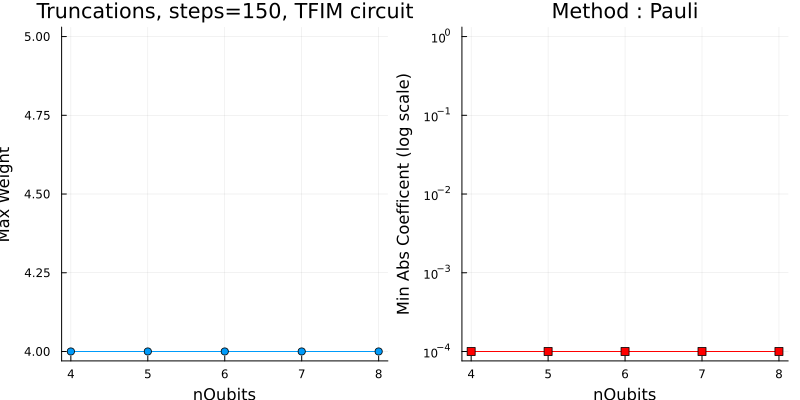

In [172]:
us.truncation_plot(Ns, TFIM_truncations_pp; method="Pauli", title="Truncations, steps=$steps, TFIM circuit", parameterName="nQubits")

No Pauli strings with a weight greater than 4 are generated with this type of model, so the truncation remains the same regardless of the number of qubits.

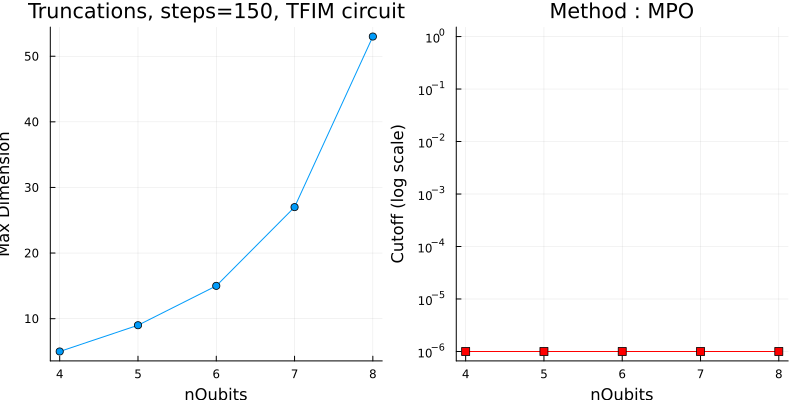

In [173]:
us.truncation_plot(Ns, TFIM_truncations_mpo; method="MPO", title="Truncations, steps=$steps, TFIM circuit", parameterName="nQubits")

On the other hand, with the MPO method, we observe that the truncation must increase; however, the complexity grows more slowly than with the exact method, which means that for a large number of qubits, the MPO method will become more efficient than the exact method. Nevertheless, it grows in contrast to the Pauli chain propagation method, which means that Pauli propagation will remain the most efficient method.

The **Pauli propagation method works very well in this case** and **saves us significant computation time** compared to the MPO propagation and exact method.

Which is no small advantage.

---

## 3.4 MFIM Hamiltonian

$$
H = \sum_j ( X_j X_{j+1} + gX_j + hZ_j ) \quad \text{with} \quad g=1/2, h=1/2
$$

In [174]:
g, h = 0.5, 0.5

(0.5, 0.5)

--------------- nqubits=4 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.002146005630493164 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=4, Min abs coeff=1e-5)
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.03742098808288574 seconds
--------- MPO method propagation ---------
Optimal truncations find : (Maxdim=16, Cutoff=1e-7)
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complet

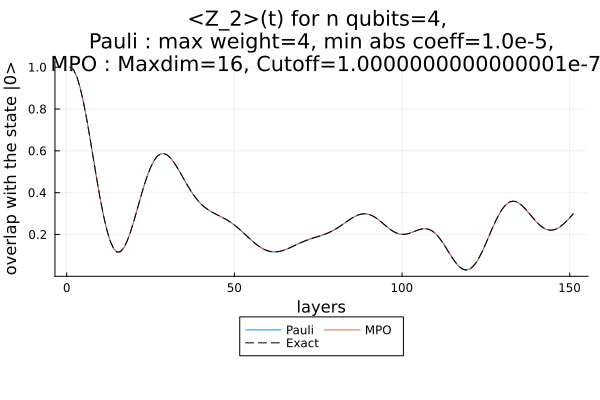

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? false
Mean matrix error (Pauli): 0.006220192454811365
Mean matrix error (MPO): 0.24600322811759365

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 0.001203698897318195
Max overlap error (MPO): 0.0019279258258120269
--------------- nqubits=5 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.008961915969848633 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=5, Min abs coeff=1e-6)
layer : 15/150 complete
layer : 30/150 complete
layer : 

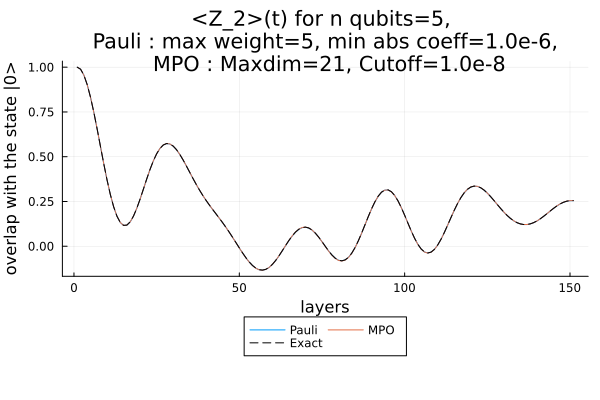

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? false
Mean matrix error (Pauli): 0.005112217975719769
Mean matrix error (MPO): 0.1850385044733725

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 0.0010275929709578357
Max overlap error (MPO): 0.001323096677908267
--------------- nqubits=6 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.052236080169677734 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=6, Min abs coeff=1e-6)
layer : 15/150 complete
layer : 30/150 complete
layer : 4

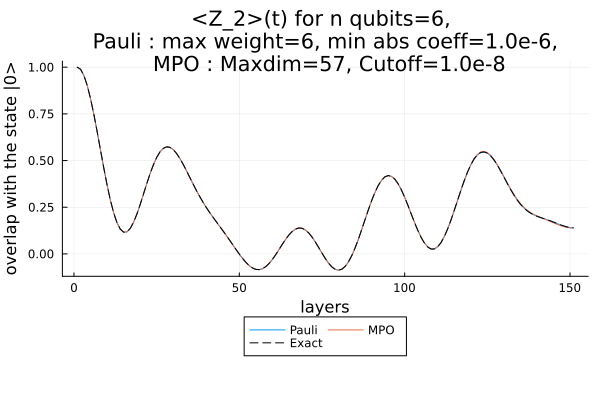

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? false
Mean matrix error (Pauli): 0.0036222317729361487
Mean matrix error (MPO): 0.12930733050482435

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 0.0014069698257206387
Max overlap error (MPO): 0.004322769514226055
--------------- nqubits=7 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.25562000274658203 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=7, Min abs coeff=1e-6)
layer : 15/150 complete
layer : 30/150 complete
layer : 

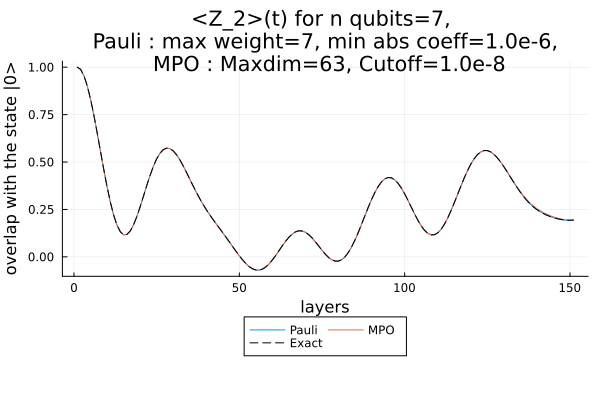

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 0.0025317946581730477
Mean matrix error (MPO): 0.08554413662171856

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 0.0012000392181336084
Max overlap error (MPO): 0.005412774224838768
--------------- nqubits=8 ---------------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 3.650477170944214 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=8, Min abs coeff=1e-6)
layer : 15/150 complete
layer : 30/150 complete
layer : 45/

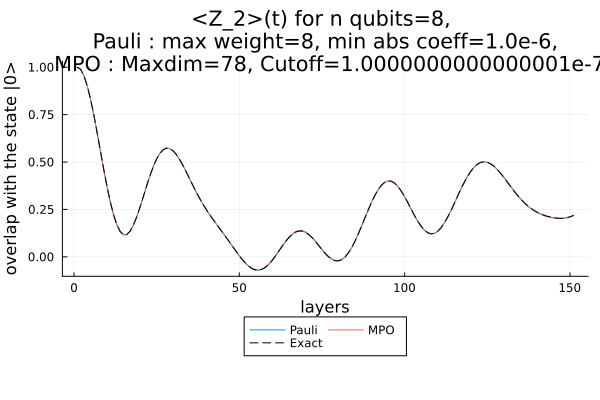

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 0.0017080500515966603
Mean matrix error (MPO): 0.05567754034156285

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 0.0009176469270781862
Max overlap error (MPO): 0.002777432248763867


In [175]:
MFIM_times_exact, MFIM_times_pp, MFIM_times_mpo = Float64[], Float64[], Float64[]
MFIM_truncations_mpo, MFIM_truncations_pp = Tuple{Int64, Float64}[], Tuple{Int64, Float64}[]

for nqubits in Ns
  println("--------------- nqubits=$nqubits ---------------")
  # Init methods
  MFIM_circuit_exact, Z_i, ψ0_exact, MFIM_circuit_pp, Z_i_pauliString, parameters, ψ0_pp, MFIM_circuit_mpo, sites, Z_i_mpo, ψ0_mps = initialisation(nqubits, steps, g, h, τ, i)

  # Exact method
  println("--------- Exact method propagation ---------")
  Zi_t_exact, result_exact = ext.propagate_layerbylayer(MFIM_circuit_exact, Z_i; ψ0=ψ0_exact)
  overlap_exact = result_exact["overlap"]

  # Pauli
  println("--------- method Pauli propagation ---------")
  ## test truncation
  (max_weight, min_abs_coeff) = pp.find_truncations(truncation_tolerance, MFIM_circuit_pp, Z_i_pauliString, steps, parameters)

  ## optimal truncation application
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(MFIM_circuit_pp, Z_i_pauliString, steps, parameters; max_weight, min_abs_coeff, ψ0=ψ0_pp)
  overlap_pp = result_pp["overlap"]

  ## pauli sum -> matrix
  Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)

  # MPO
  println("--------- MPO method propagation ---------")
  ## test truncation
  (maxdim, cutoff) = mpo.find_truncations(truncation_tolerance, MFIM_circuit_mpo, Z_i_mpo)

  ## optimal truncation application
  Zi_t_mpo, result_mpo = mpo.propagate_layerbylayer(MFIM_circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0=ψ0_mps)
  overlap_mpo = result_mpo["overlap"]

  ## Itensor -> matrix
  Zi_t_mpo_matrix = mpo.compute_matrix(Zi_t_mpo, sites)

  # plot and print to see if its good
  println("--------- Plot & Result ---------")
  us.overlap_with_Zi_plot(nqubits, overlap_pp, overlap_mpo, overlap_exact, i, max_weight, min_abs_coeff, maxdim, cutoff)
  us.print_methods_error(Zi_t_exact, Zi_t_pauli_propagation_matrix, Zi_t_mpo_matrix, overlap_exact, overlap_pp, overlap_mpo, error_tolerance; operatorName="Z$i")

  # push the time of propagation to see complexity
  push!(MFIM_truncations_pp, (max_weight, min_abs_coeff))
  push!(MFIM_truncations_mpo, (maxdim, cutoff))
  push!(MFIM_times_exact, result_exact["time"])
  push!(MFIM_times_pp, result_pp["time"])
  push!(MFIM_times_mpo, result_mpo["time"])
end


---

## 3.6 MFIM Result

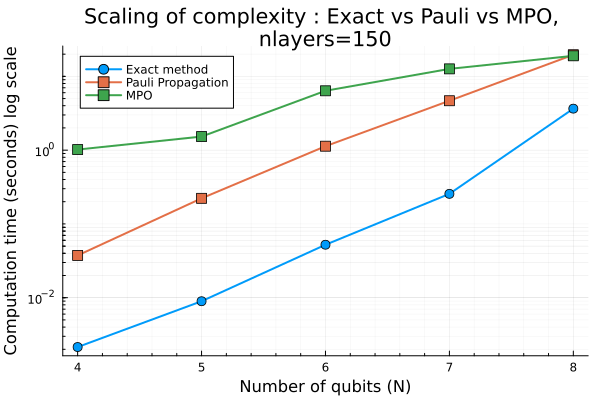

In [176]:
us.complexity_plot(Ns, steps, MFIM_times_exact, MFIM_times_pp, MFIM_times_mpo; logscale=true)

The complexity of the MPO method appears to increase linearly with the number of qubits, unlike the Pauli method, which seems to follow a $4^N$ law. This means that the MPO method should be more efficient for this type of problem when dealing with a large number of qubits.

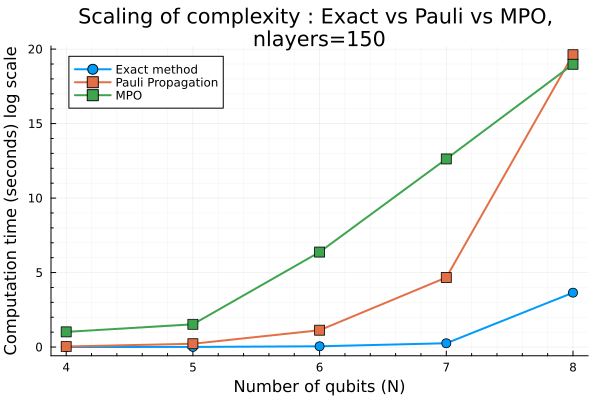

In [177]:
us.complexity_plot(Ns, steps, MFIM_times_exact, MFIM_times_pp, MFIM_times_mpo)

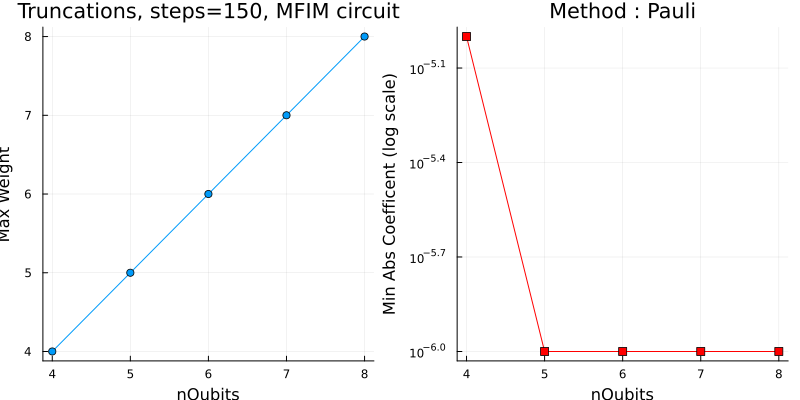

In [178]:
us.truncation_plot(Ns, MFIM_truncations_pp; method="Pauli", title="Truncations, steps=$steps, MFIM circuit", parameterName="nQubits")

From the graph showing the trend in truncations for the Pauli method, we can see that for a maximum weight below the number of Qubits, our method troncate $c_\alpha$ wich are important for the physical state.

This seems consistent with the type of circuit through which we propagate our observable.
In fact, a circuit consisting of $X$ and $Z$ gates, as well as gates applied to nearby neighbors $XX$, generates a strong correlation between the qubits. Consequently, a max weight that is too small avoids strong correlations and thus takes us drastically away from the exact physical state, which is highly correlated.

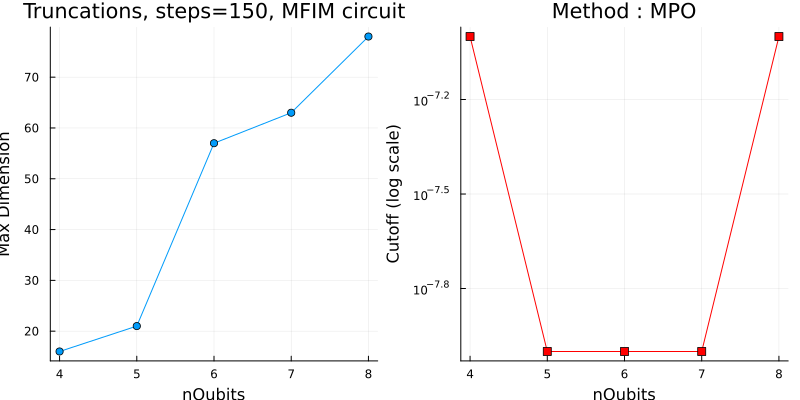

In [179]:
us.truncation_plot(Ns, MFIM_truncations_mpo; method="MPO", title="Truncations, steps=$steps, MFIM circuit", parameterName="nQubits")


---

# 4. Conclusion

- For TFIM: Pauli chain propagation,
- For MFIM: Propagation using MPO decomposition.

---

## References

### Paper
- [Pauli Propagation](https://arxiv.org/abs/2505.21606)
- [Tensor Network](https://tensornetwork.org/mps/algorithms/timeevo/tebd.html)

### Julia Package
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [PauliPropagation.jl](https://github.com/MSRudolph/PauliPropagation.jl)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)

### Other
- Latex Tiks documentation https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts
